# TT-21 — KNN Regressor: Dinh gia nha theo "cac can tuong tu"

**Bai toan:** mo phong dung cach mot tham dinh vien bat dong san lam viec —
tim vai can nha TUONG TU da ban gan day, lay gia trung binh (co dieu chinh)
de uoc tinh gia can can dinh gia. KNN Regressor la phien ban tu dong hoa
chinh xac cua phuong phap "so sanh" (comparable sales) nay.

**San pham thuc te:** san BDS hien thi *"Can nay uoc tinh 4,2 ty — dua tren
5 can tuong tu da ban:"* roi LIET KE 5 can do. Day la uu the rieng cua KNN:
khong chi cho con so ma chi ra duoc CAN CU (nhung can nha cu the nao).

**Vi sao dung lai bo California Housing (nhu TT-11):** de so sanh TRUC TIEP
hai triet ly mo hinh — Linear Regression (mo hinh THAM SO, hoc ra 1 cong
thuc chung cho toan bo du lieu) vs KNN (mo hinh PHI THAM SO, "ghi nho" du
lieu va tra loi dua tren hang xom gan nhat). Voi bat dong san — noi "vi tri,
vi tri, vi tri" quyet dinh gia — gia thiet "hang xom gan nhau thi gia giong
nhau" cua KNN RAT PHU HOP, nen ky vong KNN thang Linear Regression.

### Mach logic cua notebook

| Muc | Cau hoi tra loi | Tieu chi README |
|---|---|---|
| 1 | Du lieu co gi bat thuong can loc? | buoc 1 |
| 2 | Moc so sanh (Dummy, Linear) la bao nhieu? | buoc 2 |
| 3 | Khong chuan hoa thi sao? -> bang CO/KHONG scale | buoc 3–4 ✅ |
| 4 | K bao nhieu la tot? Vi sao K=1 cho RMSE train = 0? | buoc 5 ✅ |
| 5–6 | `uniform` vs `distance`, `euclidean` vs `manhattan` | buoc 6–7 ✅ |
| 7 | ⭐ Tang trong so vi tri co giup khong? | buoc 8 ✅ |
| 8 | ⭐ 5 "can tuong tu" co that su giong khong? | buoc 9 ✅ |
| 9 | ⭐ Linear vs KNN vs RF: RMSE + thoi gian + giai thich | buoc 10 ✅ |
| 10 | KNN cham dan khi du lieu tang? | buoc 11 ✅ |
| 11 | Chung minh han che "khong ngoai suy" | han che ✅ |
| 12–13 | Luu model, tong ket | san pham nop |

## 0. KNN Regressor hoat dong the nao — vi du tinh tay

Truoc khi dung sklearn, tu tinh lai 1 du doan bang numpy de hieu **chinh xac**
mo hinh lam gi. Gia su co 6 can da ban, moi can mo ta bang 2 dac trung
(da chuan hoa) va 1 can moi can dinh gia:

1. Tinh khoang cach Euclid tu can moi den TUNG can da ban: $d_i = \sqrt{\sum_j (x_j - x_{ij})^2}$
2. Sap xep, lay K=3 can gan nhat
3. `weights='uniform'`: $\hat y = \frac{1}{K}\sum y_i$ — trung binh cong
4. `weights='distance'`: $\hat y = \frac{\sum y_i / d_i}{\sum 1/d_i}$ — can cang gan, phieu cang nang

**Diem mau chot:** KNN KHONG "hoc" tham so nao ca. `fit()` chi luu du lieu
(va dung cay chi muc de tim nhanh). Moi tinh toan dien ra luc `predict()`.

In [1]:
%matplotlib inline
import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path.cwd().parent            # notebook nam trong notebooks/ -> len 1 cap
REPORTS_DIR = BASE_DIR / "reports"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR.mkdir(exist_ok=True)
sys.path.append(str(BASE_DIR / "src"))  # de import ham dung chung voi train.py
from features import load_raw, filter_outliers, split_xy, nhan_vi_tri  # noqa: E402

RANDOM_STATE = 42
TARGET = "MedHouseVal"
np.random.seed(RANDOM_STATE)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


print("San sang.")

San sang.


**Giai thich code:** nap thu vien, khai bao duong dan `reports/`, `models/`
va import 3 ham tu `src/features.py` — dung CHUNG voi `src/train.py` de
notebook va script train cho ra CUNG mot tap du lieu sach (tranh loi "notebook
loc outlier kieu A, script loc kieu B"). Ham `rmse` viet rieng vi RMSE cung
don vi voi gia nha (100.000 USD) nen de doc hon MSE.

In [2]:
# 6 can da ban: 2 dac trung da chuan hoa (vd: vi tri, thu nhap) + gia (x100k USD)
X_toy = np.array([[0.0, 0.0], [0.2, 0.1], [1.0, 1.2], [0.1, -0.3], [2.0, 2.0], [-1.5, 0.5]])
y_toy = np.array([2.0, 2.4, 3.5, 1.8, 4.5, 1.0])
x_moi = np.array([0.1, 0.0])
K = 3

d = np.sqrt(((X_toy - x_moi) ** 2).sum(axis=1))   # buoc 1: khoang cach toi tung can
idx = np.argsort(d)[:K]                            # buoc 2: chi so K can gan nhat
y_uniform = y_toy[idx].mean()                      # buoc 3
w = 1 / d[idx]
y_distance = (w * y_toy[idx]).sum() / w.sum()      # buoc 4

print("Khoang cach:", np.round(d, 3))
print("K=3 can gan nhat:", idx, "-> gia", y_toy[idx])
print(f"Tinh tay   uniform = {y_uniform:.4f}   distance = {y_distance:.4f}")

# Doi chieu voi sklearn: phai ra dung cung so
for wmode in ["uniform", "distance"]:
    sk = KNeighborsRegressor(n_neighbors=K, weights=wmode).fit(X_toy, y_toy)
    print(f"sklearn    {wmode:8s}= {sk.predict([x_moi])[0]:.4f}")

Khoang cach: [0.1   0.141 1.5   0.3   2.759 1.676]
K=3 can gan nhat: [0 1 3] -> gia [2.  2.4 1.8]
Tinh tay   uniform = 2.0667   distance = 2.1059


sklearn    uniform = 2.0667
sklearn    distance= 2.1059


**Doc ket qua:** so tinh tay trung khop sklearn — xac nhan cong thuc o README
muc 1. Can so 4 (gia 4,5) o xa nen KHONG duoc tinh; `distance` keo du doan ve
phia 2 can sat nhat (gia 2,0 va 2,4) hon so voi trung binh cong.

## 1. Nap du lieu va xu ly outlier

California Housing: 20.640 khu vuc dan cu (block group), 8 dac trung, nhan
`MedHouseVal` (don vi 100.000 USD). Moi dong la 1 KHU, khong phai 1 can —
nhung ta van goi la "can" cho gan voi nghiep vu tham dinh.

In [3]:
df_raw = load_raw()
print(f"Du lieu goc: {df_raw.shape[0]:,} dong x {df_raw.shape[1]} cot")
df_raw[["AveRooms", "AveBedrms", "AveOccup", "Population"]].describe()

Du lieu goc: 20,640 dong x 9 cot


,AveRooms,AveBedrms,AveOccup,Population
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,5.429000,1.096675,3.070655,1425.476744
std,2.474173,0.473911,10.386050,1132.462122
min,0.846154,0.333333,0.692308,3.000000
25%,4.440716,1.006079,2.429741,787.000000
50%,5.229129,1.048780,2.818116,1166.000000
75%,6.052381,1.099526,3.282261,1725.000000
max,141.909091,34.066667,1243.333333,35682.000000


**Doc ket qua:** `AveRooms` max ~142 phong/ho, `AveOccup` max ~1.243
nguoi/ho — RO RANG la loi du lieu hoac khu vuc cuc doan bat thuong (ky tuc
xa, trai giam...), khong phai tin hieu that ve gia. KNN dac biet nhay cam voi
cac diem nay vi chung keo gian `StandardScaler` (std bi phong to) lam cac can
binh thuong bi "don" lai gan nhau.

**Giai thich code `filter_outliers`:** giu dong co `AveRooms <= 15`,
`AveOccup <= 10`, `AveBedrms <= 5` — nguong rong rai, chi cat phan duoi cuc
doan (~0,7% du lieu). Sau do `train_test_split` 80/20 voi `random_state=42`
de moi mo hinh duoc cham tren CUNG mot tap test.

In [4]:
df = filter_outliers(df_raw)
print(f"Sau khi loc: {df.shape[0]:,} dong (bo {df_raw.shape[0]-df.shape[0]} dong bat thuong)")

X, y = split_xy(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

Sau khi loc: 20,495 dong (bo 145 dong bat thuong)
Train: 16,396  Test: 4,099


## 2. Baseline: DummyRegressor + Linear Regression (doi chieu TT-11)

- `DummyRegressor(strategy="mean")`: luon doan = gia trung binh tap train. Mo
  hinh nao khong vuot moc nay la vo dung.
- `LinearRegression`: ket qua TT-11, moc chinh KNN phai vuot (tieu chi README).

In [5]:
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
dummy_rmse = rmse(y_test, pred_dummy)
print(f"Dummy  - RMSE: {dummy_rmse:.4f}")

lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)
lr_rmse, lr_r2 = rmse(y_test, pred_lr), r2_score(y_test, pred_lr)
print(f"Linear - RMSE: {lr_rmse:.4f}  R2: {lr_r2:.4f}")

Dummy  - RMSE: 1.1500
Linear - RMSE: 0.6789  R2: 0.6515


**Doc ket qua:** R² ~0,65 — khop voi TT-11. Linear Regression gia dinh moi
dac trung anh huong TUYEN TINH va DONG NHAT tren toan bang: no chi hoc duoc
"cang ve phia Tay/Nam thi gia tang deu", KHONG bat duoc cac "diem nong" cuc
bo (ven bien San Francisco, Los Angeles) — la quan he phi tuyen, cuc bo cua
Latitude/Longitude. Day chinh la khe ho ma KNN khai thac.

## 3. ⚠️ KNN KHONG chuan hoa vs CO chuan hoa

**Logic:** KNN do khoang cach tren dac trung THO. `Population` dao dong hang
nghin, `Latitude`/`Longitude` chi lech vai don vi trong ca bang California.
Khi binh phuong va cong lai, chenh lech 500 nguoi (=250.000) nuot chung
chenh lech 2 do vi do (=4). KNN se tim "hang xom co dan so giong nhau" chu
khong phai "hang xom o gan nhau".

Truoc het xem do lech chuan (std) cua tung cot — chinh la "trong so ngam"
cua moi dac trung trong khoang cach khi chua scale:

In [6]:
X_train.std().sort_values(ascending=False).to_frame("std (thang do tho)").round(3)

,std (thang do tho)
Population,1148.228
HouseAge,12.616
Latitude,2.130
Longitude,2.006
MedInc,1.909
AveRooms,1.323
AveOccup,0.766
AveBedrms,0.162


In [7]:
# (a) KHONG scale: dua thang X tho vao KNN
knn_noscale = KNeighborsRegressor(n_neighbors=5, n_jobs=-1).fit(X_train, y_train)
pred_noscale = knn_noscale.predict(X_test)

# (b) CO scale, K=5 mac dinh: gom scaler + KNN vao 1 Pipeline
pipe_k5 = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsRegressor(n_neighbors=5, n_jobs=-1))])
pipe_k5.fit(X_train, y_train)
pred_k5 = pipe_k5.predict(X_test)

noscale_rmse, noscale_r2 = rmse(y_test, pred_noscale), r2_score(y_test, pred_noscale)
k5_rmse, k5_r2 = rmse(y_test, pred_k5), r2_score(y_test, pred_k5)

bang_scale = pd.DataFrame({
    "RMSE": [dummy_rmse, lr_rmse, noscale_rmse, k5_rmse],
    "R2": [np.nan, lr_r2, noscale_r2, k5_r2],
}, index=["Dummy (trung binh)", "Linear Regression", "KNN K=5 KHONG scale", "KNN K=5 CO scale"])
bang_scale.to_csv(REPORTS_DIR / "so_sanh_scale.csv")
bang_scale.round(4)

,RMSE,R2
Dummy (trung binh),1.1500,NaN
Linear Regression,0.6789,0.6515
KNN K=5 KHONG scale,1.0658,0.1410
KNN K=5 CO scale,0.5909,0.7360


**Giai thich code:** `Pipeline([("scale", ...), ("knn", ...)])` dam bao
`StandardScaler` chi `fit` tren X_train (hoc mean/std cua train), roi dung
dung mean/std do de bien doi X_test — khong ro ri thong tin test vao train.
Hai mo hinh giong het nhau (K=5), chi khac buoc scale -> moi chenh lech la
DO chuan hoa.

**Doc ket qua:** khong scale, KNN K=5 chi R² ~0,14 — TE HON CA Linear
Regression, gan voi Dummy. Chi them 1 dong `StandardScaler`, R² nhay len
~0,74 va da VUOT Linear Regression ma chua tune gi. Day la bai hoc so 1 cua
moi thuat toan dua tren khoang cach (KNN, SVR, K-Means): **scale la bat buoc**.

## 4. RMSE train/test theo K = 1..50

`K` la sieu tham so quan trong nhat cua KNN:
- K nho -> "nho" chi tiet tung diem, nhay voi nhieu (overfit, variance cao)
- K lon -> trung binh hoa ca nhung can khong con giong (underfit, bias cao)

**Giai thich code:** scale X 1 lan ngoai vong lap (`X_train_s`, `X_test_s`)
de khong phai fit lai scaler 50 lan. Moi K: fit KNN, tinh RMSE tren CA train
lan test de ve 2 duong. Dung `weights="uniform"` de thay hien tuong kinh dien
(xem ghi chu cuoi muc).

K=1  -> RMSE train: 0.000000   RMSE test: 0.7643
K=50 -> RMSE train: 0.5930   RMSE test: 0.5928
K tot nhat (RMSE test nho nhat): K=10  RMSE=0.5740


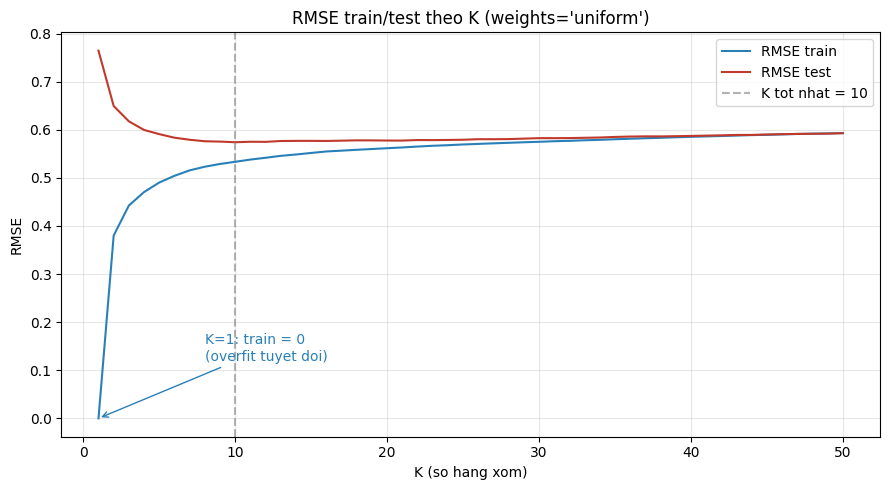

In [8]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

Ks = list(range(1, 51))
train_rmses, test_rmses, test_rmses_dist = [], [], []
for k in Ks:
    m = KNeighborsRegressor(n_neighbors=k, weights="uniform", n_jobs=-1).fit(X_train_s, y_train)
    train_rmses.append(rmse(y_train, m.predict(X_train_s)))
    test_rmses.append(rmse(y_test, m.predict(X_test_s)))
    # luu san RMSE test cua ban 'distance' de dung o muc 5
    md_ = KNeighborsRegressor(n_neighbors=k, weights="distance", n_jobs=-1).fit(X_train_s, y_train)
    test_rmses_dist.append(rmse(y_test, md_.predict(X_test_s)))

best_k = Ks[int(np.argmin(test_rmses))]
print(f"K=1  -> RMSE train: {train_rmses[0]:.6f}   RMSE test: {test_rmses[0]:.4f}")
print(f"K=50 -> RMSE train: {train_rmses[-1]:.4f}   RMSE test: {test_rmses[-1]:.4f}")
print(f"K tot nhat (RMSE test nho nhat): K={best_k}  RMSE={min(test_rmses):.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(Ks, train_rmses, label="RMSE train", color="#2980b9")
ax.plot(Ks, test_rmses, label="RMSE test", color="#c0392b")
ax.axvline(best_k, color="gray", ls="--", alpha=0.6, label=f"K tot nhat = {best_k}")
ax.annotate("K=1: train = 0\n(overfit tuyet doi)", xy=(1, 0), xytext=(8, 0.12),
            arrowprops=dict(arrowstyle="->", color="#2980b9"), color="#2980b9")
ax.set_xlabel("K (so hang xom)"); ax.set_ylabel("RMSE")
ax.set_title("RMSE train/test theo K (weights='uniform')")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "rmse_theo_K.png", dpi=110)
plt.show()

**Vi sao K=1 cho RMSE train = 0:** khi du doan cho chinh mot diem TRONG tap
train, hang xom gan nhat cua no LA CHINH NO (khoang cach = 0). Voi K=1 mo
hinh chi "tra bai" dung gia da thay -> sai so 0. Day la overfit tuyet doi:
RMSE train = 0 nhung RMSE test cao NHAT tren ca duong cong.

Khi K tang, RMSE train TANG DAN (phai trung binh voi hang xom KHAC minh),
RMSE test giam manh roi cham day quanh K≈10, sau do tang nhe (qua "mo").
Hai duong gap nhau o K lon = mo hinh het overfit nhung bat dau underfit.

**Bai hoc: khong bao gio chon K dua tren RMSE train** — no luon chi ve K=1.

**Luu y ky thuat:** voi `weights='distance'`, RMSE train = 0 voi MOI K (khong
chi K=1) vi diem trung chinh no co $1/d = \infty$ -> sklearn gan toan bo
trong so cho no. Vi vay tu day tro di moi so sanh deu dung **tap TEST**.

## 5. So sanh `weights='uniform'` vs `'distance'`

So sanh tren TOAN BO dai K (khong chi 1 diem K=10) de ket luan chac chan hon.
Du lieu da tinh san trong vong lap muc 4.

    uniform  distance
K                    
1    0.7643    0.7643
5    0.5909    0.5885
10   0.5740    0.5706
20   0.5775    0.5729
50   0.5928    0.5867

Tai K=10: uniform=0.5740  distance=0.5706


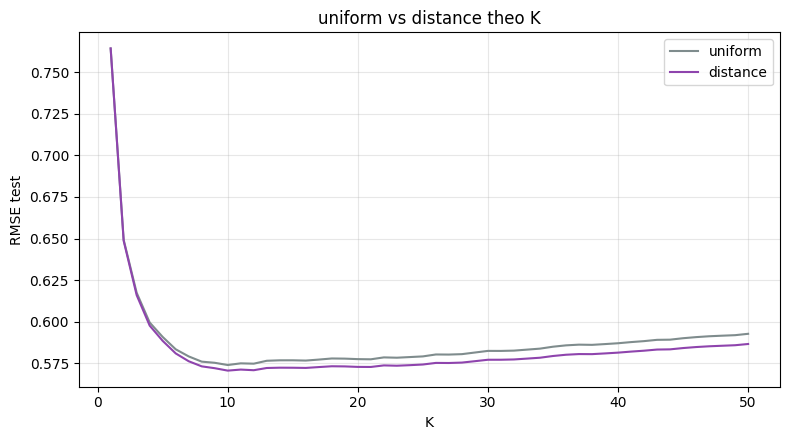

In [9]:
bang_w = pd.DataFrame({"uniform": test_rmses, "distance": test_rmses_dist}, index=Ks)
print(bang_w.loc[[1, 5, 10, 20, 50]].round(4).rename_axis("K").to_string())
print(f"\nTai K={best_k}: uniform={bang_w.loc[best_k,'uniform']:.4f}  distance={bang_w.loc[best_k,'distance']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(Ks, test_rmses, label="uniform", color="#7f8c8d")
ax.plot(Ks, test_rmses_dist, label="distance", color="#8e44ad")
ax.set_xlabel("K"); ax.set_ylabel("RMSE test"); ax.set_title("uniform vs distance theo K")
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
fig.savefig(REPORTS_DIR / "uniform_vs_distance.png", dpi=110)
plt.show()

**Doc ket qua:** `distance` tot hon hoac bang `uniform` o hau het K, va
khoang cach giua 2 duong **ro hon khi K lon**: voi K=50 `uniform` bi keo boi
cac can o ria nhom (khac xa), con `distance` tu dong giam tieng noi cua
chung -> ben hon voi lua chon K. O K≈10 chenh lech nho vi 10 can gan nhat
deu kha giong nhau. Ket luan nghiep vu: giong tham dinh vien — can **cang
giong** thi cang tin gia cua no.

## 6. So sanh metric: `euclidean` vs `manhattan`

- Euclid: $\sqrt{\sum (x_j - x'_j)^2}$ — binh phuong nen **phat nang** 1 chieu lech lon
- Manhattan: $\sum |x_j - x'_j|$ — cong deu, 1 chieu lech lon khong ap dao

In [10]:
metric_res = {}
for metric in ["euclidean", "manhattan"]:
    m = KNeighborsRegressor(n_neighbors=best_k, weights="distance", metric=metric, n_jobs=-1).fit(X_train_s, y_train)
    p = m.predict(X_test_s)
    metric_res[metric] = rmse(y_test, p)
    print(f"metric={metric:10s} RMSE: {metric_res[metric]:.4f}  R2: {r2_score(y_test, p):.4f}")

metric=euclidean  RMSE: 0.5706  R2: 0.7537


metric=manhattan  RMSE: 0.5523  R2: 0.7693


**Doc ket qua bat ngo:** `manhattan` tot hon ro `euclidean`. Ly giai: sau khi
scale, 1–2 dac trung it lien quan (vd `Population`, `AveBedrms`) doi khi
lech lon; Euclid binh phuong phan lech do nen de bi chung "keo" chon sai
hang xom. Manhattan cong tuyen tinh nen ben hon voi nhieu dac trung nhieu.
=> Nen thu ca hai thay vi mac dinh `euclidean`.

## 7. ⭐ Thi nghiem trong so vi tri: nhan Latitude/Longitude × {1, 2, 3, 5, ...}

**Logic:** sau `StandardScaler`, 8 dac trung co trong so NGANG NHAU trong
khoang cach. Nhung voi BDS, vi tri quan trong hon so phong. Nhan 2 cot toa do
voi he so $w$ -> chenh lech vi tri bi phong to $w$ lan -> KNN buoc phai tim
hang xom GAN VE DIA LY truoc, roi moi xet giong ve thu nhap/tuoi nha.

Chay {1, 2, 3, 5} theo README, roi mo rong den x500 de tim diem dung (neu
chi thu den x5 se thay RMSE "giam mai" va ket luan sai la cang lon cang tot).

He so vi tri x1  : RMSE CV(train)=0.5900   RMSE test=0.5706


He so vi tri x2  : RMSE CV(train)=0.5533   RMSE test=0.5351


He so vi tri x3  : RMSE CV(train)=0.5330   RMSE test=0.5132


He so vi tri x5  : RMSE CV(train)=0.5071   RMSE test=0.4895


He so vi tri x10 : RMSE CV(train)=0.4813   RMSE test=0.4675


...

He so vi tri x30 : RMSE CV(train)=0.4540   RMSE test=0.4423


He so vi tri x50 : RMSE CV(train)=0.4491   RMSE test=0.4359


He so vi tri x100: RMSE CV(train)=0.4542   RMSE test=0.4329


He so vi tri x200: RMSE CV(train)=0.4679   RMSE test=0.4442


He so vi tri x500: RMSE CV(train)=0.4933   RMSE test=0.4636

-> He so tot nhat theo CV: x50
KNN CHI dung Latitude/Longitude: RMSE test=0.5256


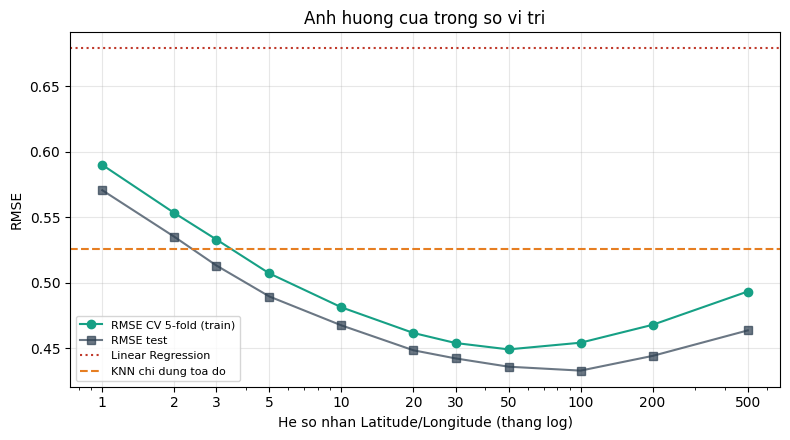

In [11]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import FunctionTransformer

loc_cols = ["Latitude", "Longitude"]
# nhan_vi_tri(X_s, w) lay tu src/features.py: copy mang DA scale roi nhan 2 cot toa do voi w.
# Dat trong module (khong dinh nghia trong notebook) de pipeline luu bang joblib roi nap lai duoc.


def pipe_vi_tri(w):
    return Pipeline([
        ("scale", StandardScaler()),
        ("vi_tri", FunctionTransformer(nhan_vi_tri, kw_args={"w": w})),
        ("knn", KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=-1)),
    ])


cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
loc_mults = [1, 2, 3, 5, 10, 20, 30, 50, 100, 200, 500]   # {1,2,3,5} theo README + mo rong de tim diem dung
loc_cv_rmses, loc_rmses = [], []
for w_loc in loc_mults:
    p = pipe_vi_tri(w_loc)
    cv_rmse = -cross_val_score(p, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error").mean()
    p.fit(X_train, y_train)
    loc_cv_rmses.append(cv_rmse)
    loc_rmses.append(rmse(y_test, p.predict(X_test)))
    print(f"He so vi tri x{w_loc:<3d}: RMSE CV(train)={cv_rmse:.4f}   RMSE test={loc_rmses[-1]:.4f}")

best_loc = loc_mults[int(np.argmin(loc_cv_rmses))]   # chon bang CV, KHONG nhin test
print(f"\n-> He so tot nhat theo CV: x{best_loc}")

# Moc so sanh: KNN CHI dung toa do (tuong duong he so vi tri = vo cung)
p_only = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=-1))])
p_only.fit(X_train[loc_cols], y_train)
only_loc_rmse = rmse(y_test, p_only.predict(X_test[loc_cols]))
print(f"KNN CHI dung Latitude/Longitude: RMSE test={only_loc_rmse:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(loc_mults, loc_cv_rmses, marker="o", color="#16a085", label="RMSE CV 5-fold (train)")
ax.plot(loc_mults, loc_rmses, marker="s", color="#2c3e50", alpha=0.7, label="RMSE test")
ax.axhline(lr_rmse, color="#c0392b", ls=":", label="Linear Regression")
ax.axhline(only_loc_rmse, color="#e67e22", ls="--", label="KNN chi dung toa do")
ax.set_xscale("log"); ax.set_xticks(loc_mults); ax.set_xticklabels(loc_mults)
ax.set_xlabel("He so nhan Latitude/Longitude (thang log)"); ax.set_ylabel("RMSE")
ax.set_title("Anh huong cua trong so vi tri"); ax.legend(fontsize=8)
ax.grid(alpha=0.3); fig.tight_layout()
fig.savefig(REPORTS_DIR / "trong_so_vi_tri.png", dpi=110)
plt.show()

**Giai thich code:** de chon he so TRUNG THUC, dong goi
"scale -> nhan toa do -> KNN" vao 1 `Pipeline` (buoc giua la
`FunctionTransformer`) roi cham bang `cross_val_score` 5-fold CHI tren tap
train. He so duoc chon theo RMSE CV; RMSE test chi de doi chieu. (Neu chon
theo test thi con so bao cao se lac quan hon thuc te.)

**Doc ket qua:**
1. Duong cong hinh chu U (thang log): RMSE giam MANH tu x1 den x5
   (~0,57 -> ~0,49 tren test), giam cham dan, dat DAY quanh x50, roi TANG
   lai khi he so qua lon (x200, x500) — luc do KNN gan nhu chi con nhin toa
   do va tien dan ve duong "KNN chi dung toa do".
2. KNN CHI dung toa do te hon han ban toi uu. Nghia la ban tot nhat la:
   **vi tri quyet dinh "khu nao"**, cac dac trung con lai (thu nhap, tuoi
   nha...) dong vai tro **phan xu trong khu** — chon trong cac can sat nhau
   ve dia ly, can nao giong nhat. Dung y nhu tham dinh vien: "cung khu pho
   truoc, roi moi so dien tich/tinh trang".
3. **Vi tri la dac trung quan trong nhat** voi gia nha — bang chung thuc
   nghiem cho gia thiet ly thuyet README muc 3.
4. Trong so dac trung la SIEU THAM SO nen tune — chi 1 phep nhan da dua KNN
   tu R² ~0,75 len ~0,86 va VUOT Random Forest (xem bang muc 9).
5. Luu y trung thuc: he so duoc chon bang CV tren train, nen con so test o
   muc 9 la uoc luong khong bi lac quan. Vi du ro: nhin test thi x100 tot
   nhat, nhung CV chon x50 — chenh lech nho, nhung nguyen tac la khong duoc
   "hé nhin" tap test khi tune.

## 8. ⭐ In ra 5 "can tuong tu" cho 3 can nha bat ky

Day la UU THE RIENG cua KNN (README muc 2): chi ra CAN CU cu the.

**Giai thich code:** `kneighbors(x, n_neighbors=5)` tra ve 2 mang:
`khoang_cach` va `chi_so` — chi_so la VI TRI HANG trong mang da dung de fit
(`X_train_s`). Vi `X_train_s` giu dung thu tu hang cua `X_train`, ta dung
`X_train.iloc[chi_so[0]]` de lay lai thong tin GOC (chua scale, doc duoc) cua
cac can do. Phai dung `.iloc` (vi tri) chu KHONG phai `.loc` (nhan index) vi
sau `train_test_split` index da bi xao tron.

In [12]:
knn_show = KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=-1).fit(X_train_s, y_train)

sample_idx = [0, 500, 1500]  # 3 can bat ky trong tap test
cot_hien = ["Latitude", "Longitude", "MedInc", "HouseAge", "AveRooms"]
for i in sample_idx:
    gia_that = y_test.iloc[i]
    gia_du_doan = knn_show.predict(X_test_s[[i]])[0]
    khoang_cach, chi_so = knn_show.kneighbors(X_test_s[[i]], n_neighbors=5)

    can_tuong_tu = X_train.iloc[chi_so[0]][cot_hien].copy()
    can_tuong_tu["Gia_100k"] = y_train.iloc[chi_so[0]].values
    can_tuong_tu["Khoang_cach"] = khoang_cach[0].round(3)

    print(f"=== Can can dinh gia #{i} (test) ===")
    print(X_test.iloc[[i]][cot_hien].to_string(index=False))
    print(f"Gia that: {gia_that*100:.0f}k USD  |  KNN uoc tinh: {gia_du_doan*100:.0f}k USD "
          f"(sai {abs(gia_du_doan-gia_that)/gia_that:.0%})")
    print("-> Dua tren 5 can tuong tu:")
    print(can_tuong_tu.to_string(index=False))
    print()

=== Can can dinh gia #0 (test) ===
 Latitude  Longitude  MedInc  HouseAge  AveRooms
    38.58     -121.3  2.8966      29.0  5.234286
Gia that: 92k USD  |  KNN uoc tinh: 102k USD (sai 10%)
-> Dua tren 5 can tuong tu:
 Latitude  Longitude  MedInc  HouseAge  AveRooms  Gia_100k  Khoang_cach
    38.69    -121.78  2.6774      31.0  5.003929     0.958        0.384
    38.51    -121.49  3.1768      30.0  5.468048     0.795        0.400
    38.07    -121.25  3.0592      28.0  5.378517     1.528        0.507
    38.25    -121.30  2.5727      27.0  4.787234     0.861        0.528
    38.22    -121.24  3.3929      28.0  5.673961     1.130        0.530

=== Can can dinh gia #500 (test) ===
 Latitude  Longitude  MedInc  HouseAge  AveRooms
    33.83    -118.03   4.225      34.0  4.635311
Gia that: 198k USD  |  KNN uoc tinh: 226k USD (sai 14%)
-> Dua tren 5 can tuong tu:
 Latitude  Longitude  MedInc  HouseAge  AveRooms  Gia_100k  Khoang_cach
    34.09    -118.08  3.7066      32.0  4.279627     2.068  

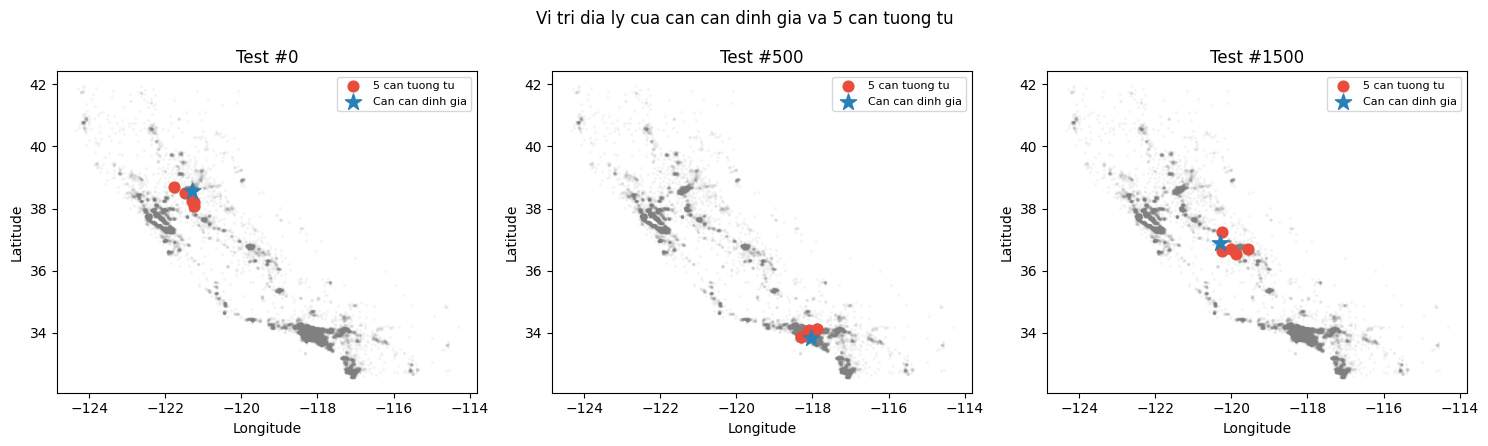

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, i in zip(axes, sample_idx):
    _, chi_so = knn_show.kneighbors(X_test_s[[i]], n_neighbors=5)
    can_tuong_tu = X_train.iloc[chi_so[0]]
    ax.scatter(X_train["Longitude"], X_train["Latitude"], s=2, alpha=0.05, color="gray")
    ax.scatter(can_tuong_tu["Longitude"], can_tuong_tu["Latitude"], s=60, color="#e74c3c", label="5 can tuong tu")
    ax.scatter(X_test.iloc[i]["Longitude"], X_test.iloc[i]["Latitude"], s=150, marker="*", color="#2980b9", label="Can can dinh gia")
    ax.set_title(f"Test #{i}"); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend(fontsize=8)
fig.suptitle("Vi tri dia ly cua can can dinh gia va 5 can tuong tu")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "can_tuong_tu_vi_du.png", dpi=110)
plt.show()

**Doc ket qua:** 5 can tuong tu cua ca 3 vi du deu nam GAN VE DIA LY voi can
can dinh gia (tren ban do chung chum sat ngoi sao) va co `MedInc`/`HouseAge`
gan giong. Kiem tra bang mat nay rat quan trong: neu "can tuong tu" thuc te
cach xa hang tram km hoac thu nhap lech gap doi, do la dau hieu chuan hoa
hoac trong so dac trung sai. Voi khach hang, danh sach nay la ly do de TIN
con so — dieu ma Random Forest/XGBoost khong cung cap duoc.

## 9. ⭐ Bang so sanh cuoi: Linear (TT-11) vs KNN (TT-21) vs Random Forest

3 tieu chi khac nhau: **RMSE** (chinh xac), **thoi gian train**, **thoi gian
du doan 1 can** (quan trong khi web can tra ket qua real-time), cong them kha
nang **giai thich**.

**Giai thich code do thoi gian:** `time.perf_counter()` (dong ho do chinh xac
cao). Du doan 1 can chi mat duoi 1 ms nen do 1 lan rat nhieu -> chay 10 lan
"lam nong" (warm-up, bo qua) roi lay trung binh 500 lan. KNN dung
`n_jobs=1` vi voi 1 truy van, chi phi khoi tao thread pool lon hon loi ich.

In [14]:
one_house, one_house_s = X_test.iloc[[0]], X_test_s[[0]]


def do_thoi_gian(model, X_fit, y_fit, x_one, n_lap=500):
    t0 = time.perf_counter(); model.fit(X_fit, y_fit); t_train = time.perf_counter() - t0
    for _ in range(10):
        model.predict(x_one)
    t0 = time.perf_counter()
    for _ in range(n_lap):
        model.predict(x_one)
    return t_train * 1000, (time.perf_counter() - t0) / n_lap * 1000


lr_train_ms, lr_pred_ms = do_thoi_gian(LinearRegression(), X_train, y_train, one_house)

knn_final = KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=1)
knn_train_ms, knn_pred_ms = do_thoi_gian(knn_final, X_train_s, y_train, one_house_s)
pred_knn_final = knn_final.predict(X_test_s)

rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_train_ms, rf_pred_ms = do_thoi_gian(rf, X_train, y_train, one_house, n_lap=100)
pred_rf = rf.predict(X_test)

# KNN + trong so vi tri tot nhat (chon bang CV o muc 7) - van giu duoc "5 can tuong tu"
knn_loc = pipe_vi_tri(best_loc)
knn_loc["knn"].set_params(n_jobs=1)
knn_loc_train_ms, knn_loc_pred_ms = do_thoi_gian(knn_loc, X_train, y_train, one_house)
pred_knn_loc = knn_loc.predict(X_test)

so_sanh = pd.DataFrame({
    "Linear Regression": [lr_rmse, lr_r2, lr_train_ms, lr_pred_ms, "Co (he so)"],
    f"KNN (K={best_k}, distance)": [rmse(y_test, pred_knn_final), r2_score(y_test, pred_knn_final),
                                   knn_train_ms, knn_pred_ms, "Co (5 can tuong tu)"],
    f"KNN + vi tri x{best_loc}": [rmse(y_test, pred_knn_loc), r2_score(y_test, pred_knn_loc),
                             knn_loc_train_ms, knn_loc_pred_ms, "Co (5 can tuong tu)"],
    "Random Forest (300 cay)": [rmse(y_test, pred_rf), r2_score(y_test, pred_rf),
                                rf_train_ms, rf_pred_ms, "Mot phan (feature importance)"],
}, index=["RMSE", "R2", "Train_ms", "Du_doan_1_can_ms", "Giai_thich_duoc"])
so_sanh.to_csv(REPORTS_DIR / "so_sanh_models.csv")
so_sanh

,Linear Regression,"KNN (K=10, distance)",KNN + vi tri x50,Random Forest (300 cay)
RMSE,0.678895,0.570649,0.43592,0.494849
R2,0.65145,0.753738,0.856294,0.814816
Train_ms,4.1052,16.4963,33.2189,2533.7216
Du_doan_1_can_ms,0.465023,0.40193,1.094709,46.876632
Giai_thich_duoc,Co (he so),Co (5 can tuong tu),Co (5 can tuong tu),Mot phan (feature importance)


**Doc ket qua:**
- KNN **THANG ro** Linear Regression ve RMSE — dat tieu chi bat buoc.
- Random Forest van tot nhat ve RMSE (ban KNN mac dinh), nhung train cham
  hon hang tram lan: "train" cua KNN chi la luu du lieu + dung cay KD-Tree.
- Bat ngo: KNN du doan 1 can **nhanh hon** Random Forest (300 cay phai duyet
  tung cay). Ly do: `algorithm='auto'` chon KD-Tree cho du lieu 8 chieu, tim
  hang xom ~O(log n) thay vi so voi toan bo du lieu. Muc 10 kiem chung.
- ⭐ **KNN + trong so vi tri** (he so chon bang CV) **VUOT Random Forest**
  ve RMSE/R², train nhanh hon ~100 lan, du doan 1 can van nhanh hon nhieu, va
  VAN giu duoc kha nang "chi ra 5 can tuong tu". Thoi gian du doan cua ban
  nay cao hon KNN thuong chu yeu vi do ca buoc scale + nhan trong so trong
  pipeline (KNN thuong do tren mang da scale san).
- Bai hoc: mot thuat toan "don gian" + hieu biet nghiep vu (vi tri quan
  trong nhat) co the thang thuat toan manh hon dung mac dinh.

## 10. ⚠️ Do thoi gian du doan khi tap train tang 1x / 5x / 10x (/ 20x)

**Logic:** `algorithm='brute'` so khoang cach voi TOAN BO n diem -> O(n);
`algorithm='auto'` (KD-Tree) chia khong gian thanh cay -> ~O(log n) khi it
chieu.

**Giai thich code:** tao tap train lon hon bang cach nhan ban `X_train` roi
cong **nhieu nho** (`+ N(0, 0.01)` tren thang da scale) — neu nhan ban
nguyen xi, cac diem trung khit nhau lam KD-Tree hoat dong khong thuc te.

 1x  n= 16,396  brute=0.866 ms   auto(KD-Tree)=0.509 ms


 5x  n= 81,980  brute=1.235 ms   auto(KD-Tree)=0.490 ms


10x  n=163,960  brute=2.025 ms   auto(KD-Tree)=0.413 ms


20x  n=327,920  brute=3.331 ms   auto(KD-Tree)=0.410 ms


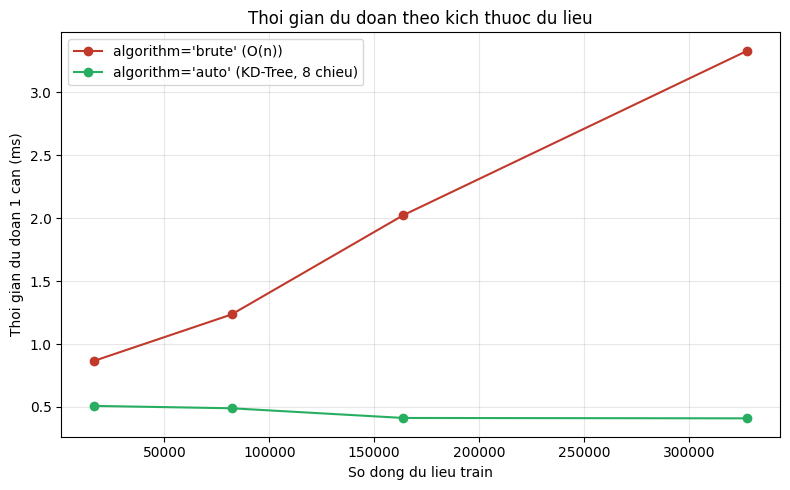

In [15]:
rng = np.random.default_rng(RANDOM_STATE)
size_mults = [1, 5, 10, 20]
sizes, brute_times, auto_times = [], [], []

for mult in size_mults:
    X_big_s = np.vstack([X_train_s] * mult)
    X_big_s = X_big_s + rng.normal(0, 0.01, X_big_s.shape) * (mult > 1)
    y_big = np.tile(y_train.values, mult)
    sizes.append(len(X_big_s))

    for algo, store in [("brute", brute_times), ("auto", auto_times)]:
        m = KNeighborsRegressor(n_neighbors=10, weights="distance", algorithm=algo, n_jobs=1).fit(X_big_s, y_big)
        for _ in range(10):
            m.predict(one_house_s)
        t0 = time.perf_counter()
        for _ in range(300):
            m.predict(one_house_s)
        store.append((time.perf_counter() - t0) / 300 * 1000)

    print(f"{mult:2d}x  n={sizes[-1]:7,d}  brute={brute_times[-1]:.3f} ms   auto(KD-Tree)={auto_times[-1]:.3f} ms")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, brute_times, marker="o", label="algorithm='brute' (O(n))", color="#c0392b")
ax.plot(sizes, auto_times, marker="o", label="algorithm='auto' (KD-Tree, 8 chieu)", color="#27ae60")
ax.set_xlabel("So dong du lieu train"); ax.set_ylabel("Thoi gian du doan 1 can (ms)")
ax.set_title("Thoi gian du doan theo kich thuoc du lieu")
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
fig.savefig(REPORTS_DIR / "thoi_gian_predict.png", dpi=110)
plt.show()

**Doc ket qua:** `brute` tang gan TUYEN TINH theo n — dung canh bao README
"KNN cham dan khi du lieu lon". KD-Tree tang rat cham vi voi 8 chieu cay van
hieu qua. **Nhung** loi ich cua KD-Tree mat dan khi so chieu tang (curse of
dimensionality — tu vai chuc chieu tro len KD-Tree gan nhu suy bien thanh
brute-force), va bo nho van tang tuyen tinh theo n. Nen canh bao "KNN khong
mo rong tot" van dung VE TONG THE — voi hang chuc trieu can, can den thu vien
tim kiem xap xi (Faiss, Annoy, HNSW).

## 11. Han che "khong ngoai suy" — chung minh bang thuc nghiem

**Logic:** du doan cua KNN la trung binh (co trong so) cua gia cac can DA
CO trong train, nen LUON nam trong $[\min y_{train}, \max y_{train}]$. Mot
can sang hon moi can da thay se bi "kep tran". Linear Regression thi cu keo
dai duong thang ra ngoai.

**Giai thich code:** lay can test #0, giu nguyen moi dac trung, chi tang dan
`MedInc` (thu nhap trung vi) len tu gia tri that toi 3 lan max trong train —
xem 2 mo hinh phan ung the nao.

Max gia trong train: 5.000   Max du doan KNN: 5.000   Max du doan Linear: 19.123


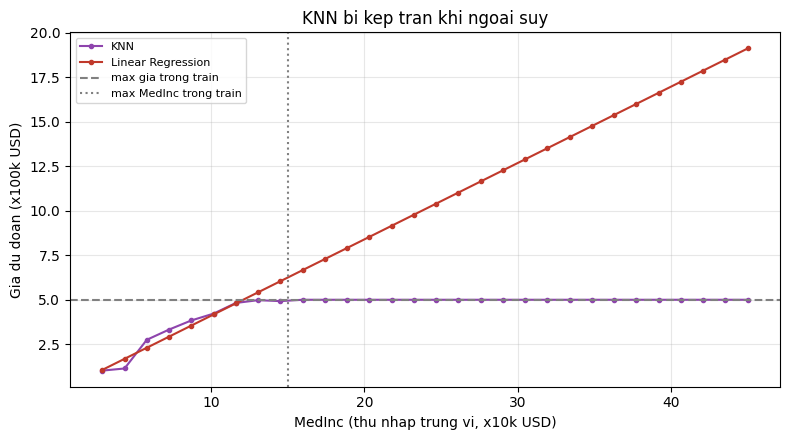

In [16]:
base = X_test.iloc[[0]].copy()
medinc_grid = np.linspace(base["MedInc"].iloc[0], X_train["MedInc"].max() * 3, 30)
fake = pd.concat([base] * len(medinc_grid), ignore_index=True)
fake["MedInc"] = medinc_grid

pred_knn_fake = knn_show.predict(scaler.transform(fake))
pred_lr_fake = lr.predict(fake)

print(f"Max gia trong train: {y_train.max():.3f}   Max du doan KNN: {pred_knn_fake.max():.3f}   "
      f"Max du doan Linear: {pred_lr_fake.max():.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(medinc_grid, pred_knn_fake, marker=".", label="KNN", color="#8e44ad")
ax.plot(medinc_grid, pred_lr_fake, marker=".", label="Linear Regression", color="#c0392b")
ax.axhline(y_train.max(), color="gray", ls="--", label="max gia trong train")
ax.axvline(X_train["MedInc"].max(), color="gray", ls=":", label="max MedInc trong train")
ax.set_xlabel("MedInc (thu nhap trung vi, x10k USD)"); ax.set_ylabel("Gia du doan (x100k USD)")
ax.set_title("KNN bi kep tran khi ngoai suy"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "ngoai_suy.png", dpi=110)
plt.show()

**Doc ket qua:** vuot qua vung du lieu train (duong cham dung), du doan KNN
di NGANG — khong bao gio vuot max gia trong train, du thu nhap tang gap ba.
Linear Regression tiep tuc tang (co the qua tay, nhung it nhat co xu huong).
Trong nghiep vu: KNN KHONG dung duoc de dinh gia biet thu/can hang sang hiem
co trong du lieu. (Rieng bo California, nhan con bi cat tran san o 5,0 — cang
lam KNN "tran" ro.)

## 12. Luu mo hinh va tong hop ket qua

Luu **Pipeline** (scaler + KNN) chu khong chi KNN: khi trien khai chi can
`pipe.predict(X_tho)`, khong phai nho tu scale — tranh loi kinh dien "quen
scale luc du doan". Luu 2 ban, cau hinh giong `src/train.py`:
- `knn_pipeline.joblib` — ban chuan theo README (scale + KNN K=10 distance)
- `knn_vi_tri_pipeline.joblib` — them buoc nhan trong so vi tri (ban tot nhat)

Cuoi cung nap lai file vua luu va du doan thu de chac chan file dung duoc.

In [17]:
final_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=-1)),
])
final_pipe.fit(X_train, y_train)
pred_final = final_pipe.predict(X_test)

MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(final_pipe, MODELS_DIR / "knn_pipeline.joblib")
joblib.dump(knn_loc.set_params(knn__n_jobs=-1), MODELS_DIR / "knn_vi_tri_pipeline.joblib")

nap_lai = joblib.load(MODELS_DIR / "knn_vi_tri_pipeline.joblib")
print(f"Nap lai model vi tri - du doan can test #0: {nap_lai.predict(X_test.iloc[[0]])[0]*100:.0f}k USD "
      f"(gia that {y_test.iloc[0]*100:.0f}k USD)")

tom_tat = {
    "n_rows_raw": int(df_raw.shape[0]),
    "n_rows_clean": int(df.shape[0]),
    "baseline": {"dummy_rmse": dummy_rmse, "linear_rmse": lr_rmse, "linear_r2": lr_r2},
    "knn_no_scale_k5": {"rmse": noscale_rmse, "r2": noscale_r2},
    "knn_scaled_k5": {"rmse": k5_rmse, "r2": k5_r2},
    "k_sweep": {"best_k": best_k, "train_rmse_k1": train_rmses[0], "test_rmse_k1": test_rmses[0],
                "test_rmse_best_k_uniform": min(test_rmses)},
    "weights_at_best_k": {"uniform": float(bang_w.loc[best_k, "uniform"]), "distance": float(bang_w.loc[best_k, "distance"])},
    "metric_rmse": metric_res,
    "location_weighting": {"mults": loc_mults, "rmse_cv": loc_cv_rmses, "rmse_test": loc_rmses,
                           "best_mult_by_cv": best_loc, "knn_only_lat_lon_rmse": only_loc_rmse},
    "knn_vi_tri": {"loc_weight": best_loc, "rmse": rmse(y_test, pred_knn_loc), "r2": float(r2_score(y_test, pred_knn_loc))},
    "final_model": {"k": best_k, "weights": "distance", "rmse": rmse(y_test, pred_final),
                    "r2": float(r2_score(y_test, pred_final)), "mae": float(mean_absolute_error(y_test, pred_final))},
    "final_comparison": so_sanh.to_dict(),
    "predict_time_scaling": {"n_rows": sizes, "brute_ms": brute_times, "auto_kdtree_ms": auto_times},
    "extrapolation": {"max_y_train": float(y_train.max()), "max_pred_knn": float(pred_knn_fake.max()),
                      "max_pred_linear": float(pred_lr_fake.max())},
}
with open(REPORTS_DIR / "tom_tat.json", "w", encoding="utf-8") as f:
    json.dump(tom_tat, f, ensure_ascii=False, indent=2, default=float)

print(json.dumps({k: tom_tat[k] for k in ["final_model", "knn_vi_tri", "metric_rmse"]}, indent=2, default=float))

Nap lai model vi tri - du doan can test #0: 115k USD (gia that 92k USD)
{
  "final_model": {
    "k": 10,
    "weights": "distance",
    "rmse": 0.570648914056126,
    "r2": 0.7537376377011419,
    "mae": 0.39459831436029164
  },
  "knn_vi_tri": {
    "loc_weight": 50,
    "rmse": 0.43591994596047656,
    "r2": 0.8562944527070602
  },
  "metric_rmse": {
    "euclidean": 0.570648914056126,
    "manhattan": 0.5522866624677173
  }
}


## 13. Ket luan

| Thi nghiem | Ket qua | Y nghia |
|---|---|---|
| KNN khong scale | R² ~0,14, te hon Linear | Scale la BAT BUOC voi mo hinh khoang cach |
| KNN scale, K=5 | Da vuot Linear | Gia thiet "hang xom giong nhau" dung voi BDS |
| RMSE theo K | K=1 train = 0, test te nhat; toi uu K≈10 | Chon K bang test/CV, khong bang train |
| uniform vs distance | distance tot hon, ro nhat khi K lon | Can cang giong cang dang tin |
| euclidean vs manhattan | manhattan tot hon | Nen thu ca 2 |
| ⭐ Trong so vi tri | U-shape, day o x50 (CV); RMSE 0,57 -> 0,44 | Vi tri quan trong nhat; cac dac trung khac "phan xu trong khu" |
| ⭐ 5 can tuong tu | Gan ve dia ly + thu nhap | KNN giai thich duoc cho khach |
| ⭐ Linear vs KNN vs RF | KNN > Linear; KNN + vi tri > RF | Hieu nghiep vu > thuat toan manh dung mac dinh |
| Thoi gian vs n | brute tang tuyen tinh, KD-Tree tang cham | Canh bao quy mo dung ve tong the |
| Ngoai suy | KNN kep tran o max y_train | Khong dung cho can hiem/hang sang |

**Han che cua KNN:**
1. **Cham khi du lieu rat lon hoac nhieu chieu** — muc 10.
2. **Khong ngoai suy duoc** — muc 11.
3. **Phai luu toan bo du lieu train** — mo hinh = du lieu; Linear chi can 9
   he so. Bo nho va do tre tang theo n.
4. **Nhay voi thang do va dac trung nhieu** — muc 3, 6, 7.

**Mo rong:** `RadiusNeighborsRegressor` (moi can trong ban kinh X km — sat
thuc te tham dinh); tune trong so vi tri bang cross-validation; dung "gia
trung binh 10 can lan can" lam 1 dac trung cho XGBoost.